# Quantum Operations
In this section we will go into the different operations that are available in Qiskit Terra. These are:  
- Single-qubit quantum gates
- Multi-qubit quantum gates
- Measurements
- Reset
- Conditionals
- State initialization

We will also show how to use the three different simulators:
- unitary_simulator
- qasm_simulator
- statevector_simulator

In [3]:
# Useful additional packages  
import matplotlib.pyplot as plt 
import numpy as np 
from math import pi

In [4]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.visualization import circuit_drawer
from qiskit.quantum_info import state_fidelity
from qiskit_aer import Aer

backend = Aer.get_backend('unitary_simulator')

## Single Qubit Quantum states
A single qubit quantum state can be written as
$$\ket{\psi} = \alpha\ket{0} + \beta\ket{1}$$
where $\alpha$ and $\beta$ are complex numbers. In a measurement the probability of the bit being in $\ket{0}$ is $\lvert\alpha\rvert^2$ and $\ket{1}$ is $\lvert\beta\rvert^2$. As a vector this is $$\ket{\psi} = \begin{bmatrix} \alpha \\ \beta \end{bmatrix}$$

Note, due to the conservation of probability $$\text{where } \lvert\alpha\rvert^2 + \lvert\beta\rvert^2 = 1$$

The single-qubit gates available are:  
- U gate
- P gate
- Identity gate
- Pauli gates
- Clifford gates
- $C3$ gates
- Standard rotation gates
We have provided a backend: unitary_simulator to to calculate the unitary matrices.

In [34]:
q = QuantumRegister(1)

## U gate
In Qiskit we have access to the general unitary using the $u$ gate, which has the following matrix form 
$$U(\theta, \phi, \lambda) = \begin{bmatrix}
\cos\left(\frac{\theta}{2}\right) & -e^{i\lambda}\sin\left(\frac{\theta}{2}\right) \\
e^{i\phi}\sin\left(\frac{\theta}{2}\right) & e^{i(\phi + \lambda)}\cos\left(\frac{\theta}{2}\right)
\end{bmatrix}$$

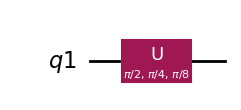

In [38]:
qc = QuantumCircuit(q)
qc.u(pi/2,pi/4,pi/8,q)
qc.draw('mpl')

In [42]:
job = backend.run(transpile(qc, backend))
job.result().get_unitary(qc, decimals = 3)

Operator([[ 0.707+0.j   , -0.653-0.271j],
          [ 0.5  +0.5j  ,  0.271+0.653j]],
         input_dims=(2,), output_dims=(2,))


## P gate
which is useful as it allows us to apply a quantum phase.
$$P(\phi) = \begin{bmatrix}
1 & 0 \\
0 & e^{i\phi}
\end{bmatrix}$$

In [45]:
qc = QuantumCircuit(q)
qc.p(pi/2, q)
qc.draw()

┌────────┐
q1: ┤ P(π/2) ├
    └────────┘

In [47]:
job = backend.run(transpile(qc, backend))
job.result().get_unitary(qc, decimals=3)

Operator([[1.+0.j, 0.+0.j],
          [0.+0.j, 0.+1.j]],
         input_dims=(2,), output_dims=(2,))


## Identity gate
The identity gate is $Id = p(0)$

In [54]:
qc = QuantumCircuit(q)
qc.id(q)
qc.draw()

┌───┐
q1: ┤ I ├
    └───┘

In [56]:
job = backend.run(transpile(qc, backend))
job.result().get_unitary(qc, decimals=3)

Operator([[1.+0.j, 0.+0.j],
          [0.+0.j, 1.+0.j]],
         input_dims=(2,), output_dims=(2,))


## Pauli gates
### $X$: bit-flip gate
The bit-flip gate $X$ is defined as:
$$X = \begin{bmatrix} 0 & 1 \\ 1 & 0 \end{bmatrix} \quad$$

In [62]:
qc = QuantumCircuit(1)
qc.x(0)
qc.draw()

┌───┐
q: ┤ X ├
   └───┘

In [64]:
job = backend.run(transpile(qc, backend))
job.result().get_unitary(qc, decimals=3)

Operator([[0.+0.j, 1.+0.j],
          [1.+0.j, 0.+0.j]],
         input_dims=(2,), output_dims=(2,))


### $Y$: bit- and phase-flip gate
The $Y$ gate is definde as : 
$$Y = \begin{bmatrix} 0 & -i \\ i & 0 \end{bmatrix} \quad $$

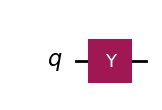

In [68]:
qc = QuantumCircuit(1)
qc.y(0)
qc.draw('mpl')

In [70]:
job = backend.run(transpile(qc, backend))
job.result().get_unitary(qc, decimals=3)

Operator([[0.-0.j, 0.-1.j],
          [0.+1.j, 0.+0.j]],
         input_dims=(2,), output_dims=(2,))


### $Z$ : phase-flip gate
The phase-flip gate $Z$ is defined as:
$$Z = \begin{bmatrix} 1 & 0 \\ 0 & -1 \end{bmatrix}$$

In [74]:
qc = QuantumCircuit(1)
qc.z(0)
qc.draw()

┌───┐
q: ┤ Z ├
   └───┘

In [76]:
transpiled_circuit = transpile(qc, backend)
job = backend.run(transpiled_circuit)
results = job.result()
results.get_unitary(qc, decimals=3)

Operator([[ 1.+0.j,  0.+0.j],
          [-0.+0.j, -1.+0.j]],
         input_dims=(2,), output_dims=(2,))


## Clifford gates
## Hadamard gate
$$H = \frac{1}{\sqrt{2}} \begin{bmatrix}
1 & 1 \\
1 & -1
\end{bmatrix}$$

In [20]:
qc = QuantumCircuit(1)
qc.h(0)
qc.draw()

┌───┐
q: ┤ H ├
   └───┘

In [9]:
backend = Aer.get_backend('unitary_simulator')
job = backend.run(transpile(qc, backend))
job.result().get_unitary(qc, decimals = 3)

Operator([[ 0.707+0.j,  0.707-0.j],
          [ 0.707+0.j, -0.707+0.j]],
         input_dims=(2,), output_dims=(2,))


## $S$ or $\sqrt{Z}$ phase gate
$$\sqrt{Z} = S = \begin{bmatrix}
1 & 0 \\
0 & i
\end{bmatrix}$$

In [18]:
qc = QuantumCircuit(1)
qc.s(0)
qc.draw()

┌───┐
q: ┤ S ├
   └───┘

In [16]:
transpiled_qc = transpile(qc, backend)
job = backend.run(transpiled_qc)
results = job.result()
results.get_unitary(qc, decimals=3)

Operator([[1.+0.j, 0.+0.j],
          [0.+0.j, 0.+1.j]],
         input_dims=(2,), output_dims=(2,))


## $S^\dagger$ or conjugate of $\sqrt{Z}$ gate
$$S^\dagger = \begin{bmatrix}
1 & 0 \\
0 & -i
\end{bmatrix}$$

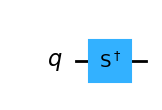

In [25]:
qc = QuantumCircuit(1)
qc.sdg(0)
qc.draw('mpl')

In [31]:
job = backend.run(transpile(qc, backend))
results = job.result().get_unitary(qc, decimals=3)
print(results)

Operator([[1.+0.j, 0.+0.j],
          [0.+0.j, 0.-1.j]],
         input_dims=(2,), output_dims=(2,))


## $C3$ gates 
### $T$ or $\sqrt{S}$ gate
$$T = \begin{bmatrix}
1 & 0 \\
0 & e^{i\pi/4}
\end{bmatrix}$$

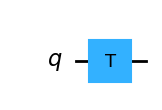

In [39]:
qc = QuantumCircuit(1)
qc.t(0)
qc.draw('mpl')

In [43]:
job = backend.run(transpile(qc, backend))
job.result().get_unitary(qc, decimals=3)

Operator([[1.   +0.j   , 0.   +0.j   ],
          [0.   +0.j   , 0.707+0.707j]],
         input_dims=(2,), output_dims=(2,))


## $T^\dagger$ or conjugate of $\sqrt{S}$ gate
$$T^\dagger = \begin{bmatrix}
1 & 0 \\
0 & e^{-i\pi/4}
\end{bmatrix}$$

In [48]:
qc = QuantumCircuit(1)
qc.tdg(0)
qc.draw()

┌─────┐
q: ┤ Tdg ├
   └─────┘

In [50]:
job = backend.run(transpile(qc, backend))
job.result().get_unitary(qc, decimals=3)

Operator([[1.   +0.j   , 0.   +0.j   ],
          [0.   +0.j   , 0.707-0.707j]],
         input_dims=(2,), output_dims=(2,))


## Standard Rotations
The standard rotation gates are those that define rotations around the Paulis
$$
R_x(\theta) = \begin{bmatrix} \cos\left(\frac{\theta}{2}\right) & -i\sin\left(\frac{\theta}{2}\right) \\ -i\sin\left(\frac{\theta}{2}\right) & \cos\left(\frac{\theta}{2}\right) \end{bmatrix}, \quad
R_y(\theta) = \begin{bmatrix} \cos\left(\frac{\theta}{2}\right) & -\sin\left(\frac{\theta}{2}\right) \\ \sin\left(\frac{\theta}{2}\right) & \cos\left(\frac{\theta}{2}\right) \end{bmatrix}, \quad
R_z(\theta) = \begin{bmatrix} e^{-i\theta/2} & 0 \\ 0 & e^{i\theta/2} \end{bmatrix}
$$

### Rotation around X-axis

In [56]:
qc = QuantumCircuit(1)
qc.rx(pi/2, 0)
qc.draw()

┌─────────┐
q: ┤ Rx(π/2) ├
   └─────────┘

In [58]:
job = backend.run(transpile(qc, backend))
job.result().get_unitary(qc, decimals=3)

Operator([[0.707+0.j   , 0.   -0.707j],
          [0.   -0.707j, 0.707+0.j   ]],
         input_dims=(2,), output_dims=(2,))


### Rotation around Y-axis

In [63]:
qc = QuantumCircuit(1)
qc.ry(pi/2, 0)
qc.draw()

┌─────────┐
q: ┤ Ry(π/2) ├
   └─────────┘

In [65]:
job = backend.run(transpile(qc, backend))
job.result().get_unitary(qc, decimals=3)

Operator([[ 0.707+0.j, -0.707+0.j],
          [ 0.707+0.j,  0.707+0.j]],
         input_dims=(2,), output_dims=(2,))


### Rotation around Z-axis

In [68]:
qc = QuantumCircuit(1)
qc.rz(pi/2, 0)
qc.draw()

┌─────────┐
q: ┤ Rz(π/2) ├
   └─────────┘

In [70]:
job = backend.run(transpile(qc, backend))
job.result().get_unitary(qc, decimals=3)

Operator([[0.707-0.707j, 0.   +0.j   ],
          [0.   +0.j   , 0.707+0.707j]],
         input_dims=(2,), output_dims=(2,))


## Multi-Qubit Gates
### Mathematical Preliminaries 
The space of a quantum computer grows exponentially with the number of qubits. For $n$ qubits the complex vector space has dimension $d = 2^n$ To describe states of a multi-qubit system, the tensor product is used to "glue together" operators and basis vectors.  
Let's start by considering a 2-qubit system. Given two operators $A$ and $B$ that each act on one qubit, the joint operator $A\otimes B$ acting on two qubits is $$A \otimes B = \begin{bmatrix} a_{11}B & a_{12}B \\ a_{21}B & a_{22}B \end{bmatrix}$$

$\ket{0} \otimes \ket{0}$ written as $\ket{00}$,  The state of an $n$-qubit system can be described using the $n$-fold tensor product of single-qubit basis vectors. Notice that the basis vectors for a 2-qubit system are 4-dimensional; in general, the basis vectors of an $n$-qubit system are $2^n$ dimensional.

## Controlled operations on qubits
A common multi-qubit gate involves the application of a gate to one qubit, conditioned on the state of another qubit. For instance, we might want to flip the state of the second qubit when the first qubit is in $\ket{0}$. Such gates are known as controlled gates. The standard multi-qubit gates consist of two-qubit gates and three-qubit gates. The two-qubit gates are:
- controlled Pauli gates
- controlled Hadamard gate
- controlled rotation gates
- controlled phase gate
- controlled u3 gate
- swap gate
 
The three-qubit gates are:
- Toffoli gate
- Fredkin gate

## Two-qubit gates
Most of the two-qubit gates are of the controlled type (the SWAP gate being the exception). In general, a controlled two-qubit gate $C_u$ acts to apply the single-qubit unitary $U$ to the second qubit when the state of the first qubit is in $\ket{1}$.

## Controlled Pauli Gates
### Controlled-X (or, Controlled-NOT) gate
The Controlled-NOT gate flips the target qubit when the control qubit is in the state $\ket{1}$ 
$$\text{CX} = \text{CNOT} = \begin{bmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 0 & 1 \\
0 & 0 & 1 & 0
\end{bmatrix}$$

In [90]:
qc = QuantumCircuit(2)
qc.cx(0, 1)
qc.draw()

q_0: ──■──
     ┌─┴─┐
q_1: ┤ X ├
     └───┘

In [92]:
job = backend.run(transpile(qc, backend))
job.result().get_unitary(qc, decimals=3)

Operator([[1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
          [0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j],
          [0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j],
          [0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j]],
         input_dims=(2, 2), output_dims=(2, 2))


#### Controlled $Y$ gate

Apply the $Y$ gate to the target qubit if the control qubit is the MSB

$$
C_Y = 
\begin{pmatrix}
1 & 0 & 0 & 0\\
0 & 1 & 0 & 0\\
0 & 0 & 0 & -i\\
0 & 0 & i & 0
\end{pmatrix},
$$

or when the LSB is the control

$$
C_Y = 
\begin{pmatrix}
1 & 0 & 0 & 0\\
0 & 0 & 0 & -i\\
0 & 0 & 1 & 0\\
0 & i & 0 & 0
\end{pmatrix}.
$$

In [4]:
from qiskit import QuantumCircuit
qc = QuantumCircuit(2)
qc.cy(0, 1)
qc.draw()

q_0: ──■──
     ┌─┴─┐
q_1: ┤ Y ├
     └───┘

In [12]:
from qiskit import transpile
from qiskit_aer import Aer

backend = Aer.get_backend('unitary_simulator')
transpiled_qc = transpile(qc, backend)
job = backend.run(transpiled_qc)
results = job.result()
results.get_unitary(qc, decimals = 3) 

Operator([[1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
          [0.-0.j, 0.-0.j, 0.-0.j, 0.-1.j],
          [0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j],
          [0.+0.j, 0.+1.j, 0.+0.j, 0.+0.j]],
         input_dims=(2, 2), output_dims=(2, 2))


#### Controlled $Z$ (or, controlled Phase-Flip) gate

Similarly, the controlled Z gate flips the phase of the target qubit if the control qubit is $\left|1\right\rangle$. The matrix looks the same regardless of whether the MSB or LSB is the control qubit:

$$
C_Z = 
\begin{pmatrix}
1 & 0 & 0 & 0\\
0 & 1 & 0 & 0\\
0 & 0 & 1 & 0\\
0 & 0 & 0 & -1
\end{pmatrix}
$$


In [15]:
qc = QuantumCircuit(2)
qc.cz(0, 1)
qc.draw()

q_0: ─■─
      │ 
q_1: ─■─

In [17]:
job = backend.run(transpile(qc, backend))
job.result().get_unitary(qc, decimals=3)

Operator([[ 1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
          [ 0.+0.j,  1.+0.j,  0.+0.j,  0.+0.j],
          [ 0.+0.j,  0.+0.j,  1.+0.j,  0.+0.j],
          [-0.+0.j, -0.+0.j, -0.+0.j, -1.+0.j]],
         input_dims=(2, 2), output_dims=(2, 2))


### Controlled Hadamard gate

Apply $H$ gate to the target qubit if the control qubit is $\left|1\right\rangle$. Below is the case where the control is the LSB qubit.

$$
C_H = 
\begin{pmatrix}
1 & 0 & 0 & 0\\
0 & \frac{1}{\sqrt{2}} & 0 & \frac{1}{\sqrt{2}}\\
0 & 0 & 1 & 0\\
0 & \frac{1}{\sqrt{2}}  & 0& -\frac{1}{\sqrt{2}}
\end{pmatrix}
$$

In [20]:
qc = QuantumCircuit(2)
qc.ch(0, 1)
qc.draw()

q_0: ──■──
     ┌─┴─┐
q_1: ┤ H ├
     └───┘

In [22]:
job = backend.run(transpile(qc, backend))
job.result().get_unitary(qc, decimals=3)

Operator([[ 1.   -0.j,  0.   +0.j, -0.   -0.j,  0.   +0.j],
          [ 0.   +0.j,  0.707-0.j,  0.   +0.j,  0.707-0.j],
          [ 0.   +0.j,  0.   +0.j,  1.   +0.j,  0.   +0.j],
          [ 0.   +0.j,  0.707+0.j,  0.   +0.j, -0.707+0.j]],
         input_dims=(2, 2), output_dims=(2, 2))


### Controlled rotation gates

#### Controlled rotation around Z-axis

Perform rotation around Z-axis on the target qubit if the control qubit (here LSB) is $\left|1\right\rangle$.

$$
C_{Rz}(\lambda) = 
\begin{pmatrix}
1 & 0 & 0 & 0\\
0 & e^{-i\lambda/2} & 0 & 0\\
0 & 0 & 1 & 0\\
0 & 0 & 0 & e^{i\lambda/2}
\end{pmatrix}
$$

In [29]:
from math import pi
qc = QuantumCircuit(2)
qc.crz(pi/2, 0, 1)
qc.draw()

q_0: ─────■─────
     ┌────┴────┐
q_1: ┤ Rz(π/2) ├
     └─────────┘

In [31]:
job = backend.run(transpile(qc, backend))
job.result().get_unitary(qc, decimals=3)

Operator([[1.   +0.j   , 0.   +0.j   , 0.   +0.j   , 0.   +0.j   ],
          [0.   +0.j   , 0.707-0.707j, 0.   +0.j   , 0.   +0.j   ],
          [0.   +0.j   , 0.   +0.j   , 1.   +0.j   , 0.   +0.j   ],
          [0.   +0.j   , 0.   +0.j   , 0.   +0.j   , 0.707+0.707j]],
         input_dims=(2, 2), output_dims=(2, 2))


### Controlled phase rotation

Perform a phase rotation if both qubits are in the $\left|11\right\rangle$ state. The matrix looks the same regardless of whether the MSB or LSB is the control qubit.

$$
C_{p}(\lambda) = 
\begin{pmatrix}
1 & 0 & 0 & 0\\
0 & 1 & 0 & 0\\
0 & 0 & 1 & 0\\
0 & 0 & 0 & e^{i\lambda}
\end{pmatrix}
$$

In [34]:
qc = QuantumCircuit(2)
qc.cp(pi/2, 0, 1)
qc.draw()

q_0: ─■───────
      │P(π/2) 
q_1: ─■───────

In [36]:
job = backend.run(transpile(qc, backend))
job.result().get_unitary(qc, decimals=3)

Operator([[1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
          [0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j],
          [0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j],
          [0.+0.j, 0.+0.j, 0.+0.j, 0.+1.j]],
         input_dims=(2, 2), output_dims=(2, 2))


### Controlled $u$ rotation

Perform controlled-$u$ rotation on the target qubit if the control qubit (here LSB) is $\left|1\right\rangle$. 

$$
C_{u}(\theta, \phi, \lambda) \equiv 
\begin{pmatrix}
1 & 0 & 0 & 0\\
0 & e^{-i(\phi+\lambda)/2}\cos(\theta/2) & 0 & -e^{-i(\phi-\lambda)/2}\sin(\theta/2)\\
0 & 0 & 1 & 0\\
0 & e^{i(\phi-\lambda)/2}\sin(\theta/2) & 0 & e^{i(\phi+\lambda)/2}\cos(\theta/2)
\end{pmatrix}.
$$

In [41]:
qc = QuantumCircuit(2)
qc.cu(pi/2, pi/2, pi/2, 0, 0, 1)
qc.draw()

q_0: ─────────■──────────
     ┌────────┴─────────┐
q_1: ┤ U(π/2,π/2,π/2,0) ├
     └──────────────────┘

In [43]:
job = backend.run(transpile(qc, backend))
job.result().get_unitary(qc, decimals=3)

Operator([[ 1.   +0.j   ,  0.   +0.j   ,  0.   +0.j   ,  0.   +0.j   ],
          [ 0.   +0.j   ,  0.707+0.j   ,  0.   +0.j   , -0.   -0.707j],
          [ 0.   +0.j   ,  0.   +0.j   ,  1.   +0.j   ,  0.   +0.j   ],
          [ 0.   +0.j   ,  0.   +0.707j,  0.   +0.j   , -0.707+0.j   ]],
         input_dims=(2, 2), output_dims=(2, 2))


### SWAP gate

The SWAP gate exchanges the two qubits. It transforms the basis vectors as

$$\left|00\right\rangle \rightarrow \left|00\right\rangle~,~\left|01\right\rangle \rightarrow \left|10\right\rangle~,~\left|10\right\rangle \rightarrow \left|01\right\rangle~,~\left|11\right\rangle \rightarrow \left|11\right\rangle,$$

which gives a matrix representation of the form

$$
\mathrm{SWAP} = 
\begin{pmatrix}
1 & 0 & 0 & 0\\
0 & 0 & 1 & 0\\
0 & 1 & 0 & 0\\
0 & 0 & 0 & 1
\end{pmatrix}.
$$

In [46]:
qc = QuantumCircuit(2)
qc.swap(0, 1)
qc.draw()

q_0: ─X─
      │ 
q_1: ─X─

In [48]:
job = backend.run(transpile(qc, backend))
job.result().get_unitary(qc, decimals=3)

Operator([[1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
          [0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j],
          [0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j],
          [0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j]],
         input_dims=(2, 2), output_dims=(2, 2))


## Three-qubit gates <a name="three_gates"/>


There are two commonly-used three-qubit gates. For three qubits, the basis vectors are ordered as

$$\left|000\right\rangle, \left|001\right\rangle, \left|010\right\rangle, \left|011\right\rangle, \left|100\right\rangle, \left|101\right\rangle, \left|110\right\rangle, \left|111\right\rangle,$$

which, as bitstrings, represent the integers $0,1,2,\cdots, 7$. Again, Qiskit uses a representation in which the first qubit is on the right-most side of the tensor product and the third qubit is on the left-most side:

$$\left|abc\right\rangle : \underset{\text{qubit 2}}{\left|a\right\rangle}\otimes \underset{\text{qubit 1}}{\left|b\right\rangle}\otimes \underset{\text{qubit 0}}{\left|c\right\rangle}.$$

### Toffoli gate ($ccx$ gate)

The Toffoli gate flips the third qubit if the first two qubits are both $\left|1\right\rangle$:

$$\left|abc\right\rangle \rightarrow \left|bc\oplus a\right\rangle \otimes \left|b\right\rangle \otimes \left|c\right\rangle.$$

In matrix form, the Toffoli gate is
$$
C_{CX} = 
\begin{pmatrix}
1 & 0 & 0 & 0 & 0 & 0 & 0 & 0\\
0 & 1 & 0 & 0 & 0 & 0 & 0 & 0\\
0 & 0 & 1 & 0 & 0 & 0 & 0 & 0\\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 1\\
0 & 0 & 0 & 0 & 1 & 0 & 0 & 0\\
0 & 0 & 0 & 0 & 0 & 1 & 0 & 0\\
0 & 0 & 0 & 0 & 0 & 0 & 1 & 0\\
0 & 0 & 0 & 1 & 0 & 0 & 0 & 0
\end{pmatrix}.
$$

In [52]:
qc = QuantumCircuit(3)
qc.ccx(0, 1, 2)
qc.draw()

q_0: ──■──
       │  
q_1: ──■──
     ┌─┴─┐
q_2: ┤ X ├
     └───┘

In [54]:
job = backend.run(transpile(qc, backend))
job.result().get_unitary(qc, decimals=3)

Operator([[1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
          [0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
          [0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
          [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j],
          [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
          [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j],
          [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j],
          [0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j]],
         input_dims=(2, 2, 2), output_dims=(2, 2, 2))


### Controlled swap gate (Fredkin Gate)

The Fredkin gate, or the *controlled swap gate*, exchanges the second and third qubits if the first qubit (LSB) is $\left|1\right\rangle$:

$$ \left|abc\right\rangle \rightarrow \begin{cases} \left|bac\right\rangle~~\text{if}~c=1 \cr \left|abc\right\rangle~~\text{if}~c=0 \end{cases}.$$

In matrix form, the Fredkin gate is

$$
C_{\mathrm{SWAP}} = 
\begin{pmatrix}
1 & 0 & 0 & 0 & 0 & 0 & 0 & 0\\
0 & 1 & 0 & 0 & 0 & 0 & 0 & 0\\
0 & 0 & 1 & 0 & 0 & 0 & 0 & 0\\
0 & 0 & 0 & 0 & 0 & 1 & 0 & 0\\
0 & 0 & 0 & 0 & 1 & 0 & 0 & 0\\
0 & 0 & 0 & 1 & 0 & 0 & 0 & 0\\
0 & 0 & 0 & 0 & 0 & 0 & 1 & 0\\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 1
\end{pmatrix}.
$$

In [57]:
qc = QuantumCircuit(3)
qc.cswap(0, 1, 2)
qc.draw()

q_0: ─■─
      │ 
q_1: ─X─
      │ 
q_2: ─X─

In [59]:
job = backend.run(transpile(qc, backend))
job.result().get_unitary(qc, decimals=3)

Operator([[1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
          [0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
          [0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
          [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j],
          [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
          [0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
          [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j],
          [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j]],
         input_dims=(2, 2, 2), output_dims=(2, 2, 2))


## Non-unitary operations <a name="non_unitary"/>

Now that we have gone through all the unitary operations in quantum circuits, we also have access to non-unitary operations. These include measurements, reset of qubits, and classical conditional operations.

### Measurements

We don't have access to all the information when we make a measurement in a quantum computer. The quantum state is projected onto the standard basis. Below are two examples showing a circuit that is prepared in a basis state and the quantum computer prepared in a superposition state.

In [67]:
from qiskit import ClassicalRegister, QuantumRegister
q = QuantumRegister(1)
c = ClassicalRegister(1)

In [69]:
qc = QuantumCircuit(q, c)
qc.measure(q, c)
qc.draw()

┌─┐
  q3: ┤M├
      └╥┘
c0: 1/═╩═
       0

In [71]:
backend = Aer.get_backend('qasm_simulator')
job = backend.run(transpile(qc, backend))
job.result().get_counts(qc)

{'0': 1024}

The simulator predicts that 100 percent of the time the classical register returns 0.

In [74]:
qc = QuantumCircuit(q, c)
qc.h(q)
qc.measure(q, c)
qc.draw()

┌───┐┌─┐
  q3: ┤ H ├┤M├
      └───┘└╥┘
c0: 1/══════╩═
            0

In [76]:
job = backend.run(transpile(qc, backend))
job.result().get_counts(qc)

{'1': 492, '0': 532}

The simulator predicts that 50 percent of the time the classical register returns 0 or 1.

### Reset
It is also possible to `reset` qubits to the $\left|0\right\rangle$ state in the middle of computation. Note that `reset` is not a Gate operation, since it is irreversible.

In [80]:
qc = QuantumCircuit(q, c)
qc.reset(q[0])
qc.measure(q, c)
qc.draw()

┌─┐
  q3: ─|0>─┤M├
           └╥┘
c0: 1/══════╩═
            0

In [82]:
job = backend.run(transpile(qc, backend))
job.result().get_counts(qc)

{'0': 1024}

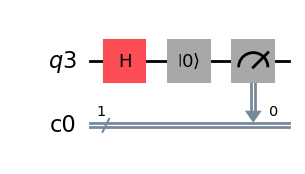

In [84]:
qc = QuantumCircuit(q, c)
qc.h(q)
qc.reset(q[0])
qc.measure(q, c)
qc.draw('mpl')

In [86]:
job = backend.run(transpile(qc, backend))
job.result().get_counts(qc)

{'0': 1024}

Here we see that for both of these circuits the simulator always predicts that the output is 100 percent in the 0 state.

### Conditional operations
It is also possible to do operations conditioned on the state of the classical register

In [90]:
qc = QuantumCircuit(q, c)
qc.x(q[0]).c_if(c, 0)
qc.measure(q,c)
qc.draw()

C:\Users\Probook\AppData\Local\Temp\ipykernel_12428\1041608833.py:2: DeprecationWarning: The method ``qiskit.circuit.instructionset.InstructionSet.c_if()`` is deprecated as of qiskit 1.3.0. It will be removed in 2.0.0.
  qc.x(q[0]).c_if(c, 0)


┌───┐ ┌─┐
  q3: ─┤ X ├─┤M├
       └─╥─┘ └╥┘
      ┌──╨──┐ ║ 
c0: 1/╡ 0x0 ╞═╩═
      └─────┘ 0

Here the classical bit always takes the value 0 so the qubit state is always flipped.

In [93]:
job = backend.run(transpile(qc, backend))
job.result().get_counts(qc)

{'1': 1024}

C:\Users\Probook\AppData\Local\Temp\ipykernel_12428\1382558340.py:4: DeprecationWarning: The method ``qiskit.circuit.instructionset.InstructionSet.c_if()`` is deprecated as of qiskit 1.3.0. It will be removed in 2.0.0.
  qc.x(q[0]).c_if(c, 0)


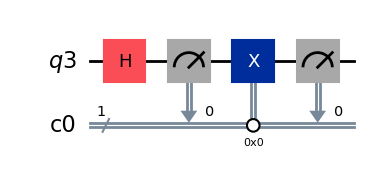

In [95]:
qc = QuantumCircuit(q, c)
qc.h(q)
qc.measure(q,c)
qc.x(q[0]).c_if(c, 0)
qc.measure(q,c)
qc.draw('mpl')

In [97]:
job = backend.run(transpile(qc, backend))
job.result().get_counts(qc)

{'1': 1024}

Here the classical bit by the first measurement is random but the conditional operation results in the qubit being deterministically put into $\left|1\right\rangle$.

## Arbitrary initialization <a name="initialization"/>
What if we want to initialize a qubit register to an arbitrary state? An arbitrary state for $n$ qubits may be specified by a vector of $2^n$ amplitudes, where the sum of amplitude-norms-squared equals 1. For example, the following three-qubit state can be prepared:

$$\left|\psi\right\rangle = \frac{i}{4}\left|000\right\rangle + \frac{1}{\sqrt{8}}\left|001\right\rangle + \frac{1+i}{4}\left|010\right\rangle + \frac{1+2i}{\sqrt{8}}\left|101\right\rangle + \frac{1}{4}\left|110\right\rangle$$

In [101]:
# Initializing a three-qubit quantum state
import math
desired_vector = [
    1 / math.sqrt(16) * complex(0, 1),
    1 / math.sqrt(8) * complex(1, 0),
    1 / math.sqrt(16) * complex(1, 1),
    0,
    0,
    1 / math.sqrt(8) * complex(1, 2),
    1 / math.sqrt(16) * complex(1, 0),
    0]


q = QuantumRegister(3)

qc = QuantumCircuit(q)

qc.initialize(desired_vector, [q[0],q[1],q[2]])
qc.draw()

┌───────────────────────────────────────────────────────────────────┐
q4_0: ┤0                                                                  ├
      │                                                                   │
q4_1: ┤1 Initialize(0.25j,0.35355,0.25+0.25j,0,0,0.35355+0.70711j,0.25,0) ├
      │                                                                   │
q4_2: ┤2                                                                  ├
      └───────────────────────────────────────────────────────────────────┘

In [105]:
backend = Aer.get_backend('statevector_simulator')
job = backend.run(transpile(qc, backend))
qc_state = job.result().get_statevector(qc)
qc_state 

Statevector([0.        +0.25j      , 0.35355339+0.j        ,
             0.25      +0.25j      , 0.        +0.j        ,
             0.        +0.j        , 0.35355339+0.70710678j,
             0.25      +0.j        , 0.        +0.j        ],
            dims=(2, 2, 2))


[Fidelity](https://en.wikipedia.org/wiki/Fidelity_of_quantum_states) is useful to check whether two states are the same or not.
For quantum (pure) states $\left|\psi_1\right\rangle$ and $\left|\psi_2\right\rangle$, the fidelity is

$$
F\left(\left|\psi_1\right\rangle,\left|\psi_2\right\rangle\right) = \left|\left\langle\psi_1\middle|\psi_2\right\rangle\right|^2.
$$

The fidelity is equal to $1$ if and only if two states are equal.

In [114]:
from qiskit.quantum_info import state_fidelity
state_fidelity(desired_vector,qc_state)

0.9999999999999996